# Plot time-height updraft samples for narrow vs. wide cells
## Use pre-computed updraft 2D mask files (make_largest_updraft_stats.py)

In [31]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
from scipy.stats import linregress
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

In [32]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [ ]:
# Specify domain name (d2, d3, d4)
domain_name = 'd4'
resolution = 'les'  # 'les' or 'meso'

# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    # "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
if domain_name == 'd2':
    rootdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
else:
    rootdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_wmask = 'stats_2d_wmask_'
# in_basename_env = 'stats_1d_env_2location_'
if resolution == 'les':
    in_basename_env = 'stats_avg1d_env21x21_'
elif resolution == 'meso':
    in_basename_env = 'stats_avg1d_env9x9_'

figdir = f'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/{resolution}/figures_avgenv20km/updraft_tracks_narrowwide/'
os.makedirs(figdir, exist_ok=True)

# Domain 4 boundaries
# lon_range = [-65., -63.1]
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]

# Environment location (0: fixed site, 1: CI location)
env_loc = 1
# Time for representative environment
time_env = -3

# Find LASSO files
files_dx = find_lasso_files(start_dates, rootdir, in_basename, domain_name)
wfiles_dx = find_lasso_files(start_dates, rootdir, in_basename_w, domain_name)
wmaskfiles_dx = find_lasso_files(start_dates, rootdir, in_basename_wmask, domain_name)
efiles_dx = find_lasso_files(start_dates, rootdir, in_basename_env, domain_name)

# files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
# files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
# files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
# wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
# wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
# wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
# wmaskfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_wmask, 'd2')
# wmaskfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_wmask, 'd3')
# wmaskfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_wmask, 'd4')
# efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
# efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
# efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files ({domain_name}): {len(files_dx)}')
print(f'Number of W files ({domain_name}): {len(wfiles_dx)}')
print(f'Number of Wmask files ({domain_name}): {len(wmaskfiles_dx)}')
print(f'Number of ENV files ({domain_name}): {len(efiles_dx)}')

# print(f'Number of stats files (D3): {len(files_d3)}')
# print(f'Number of W files (D3): {len(wfiles_d3)}')
# print(f'Number of Wmask files (D3): {len(wmaskfiles_d3)}')
# print(f'Number of ENV files (D3): {len(efiles_d3)}')

# print(f'Number of stats files (D4): {len(files_d4)}')
# print(f'Number of W files (D4): {len(wfiles_d4)}')
# print(f'Number of Wmask files (D4): {len(wmaskfiles_d4)}')
# print(f'Number of ENV files (D4): {len(efiles_d4)}')

# files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (d4): 17
Number of W files (d4): 17
Number of Wmask files (d4): 17
Number of ENV files (d4): 17


## Limit time window for analysis in each case
### The window is determined manually by examining cold pool animations to exclude periods when significant cold pools develop

In [34]:
case_hours_dict_d2 = {
    '20181129-gefs00': (12.0, 19.5),
    '20181129-gefs03': (12.0, 20.0),
    '20181129-gefs09': (12.0, 18.5),
    '20181129-gefs18': (12.0, 18.5),
    '20181204-gefs18': (12.0, 17.5),
    '20181204-gefs19': (12.0, 19.0),
    '20181205-gefs01': (12.0, 18.0),
    '20181219-eda09': (12.0, 17.0),
    '20190122-gefs01': (12.0, 21.5),
    '20190122-gefs18': (12.0, 20.25),
    '20190123-eda05': (12.0, 16.0),
    '20190123-gefs18': (12.0, 17.5),
    '20190125-eda07': (12.0, 18.5),
    '20190125-gefs11': (12.0, 18.5),
    '20190129-eda09': (12.0, 18.0),
    '20190129-gefs11': (12.0, 17.5),
    '20190208-eda03': (12.0, 19.5),
    '20190208-eda08': (12.0, 19.75),
}

In [35]:
case_hours_dict_d3 = {
    '20181129-gefs00': (12.0, 19.5),
    '20181129-gefs03': (12.0, 20.0),
    '20181129-gefs09': (12.0, 19.0),
    '20181129-gefs18': (12.0, 19.0),
    '20181204-gefs18': (12.0, 17.5),
    '20181204-gefs19': (12.0, 19.0),
    '20181205-gefs01': (12.0, 18.0),
    '20181219-eda09': (12.0, 17.0),
    '20190122-gefs01': (12.0, 21.5),
    '20190122-gefs18': (12.0, 20.5),
    '20190123-eda05': (12.0, 16.0),
    '20190123-gefs18': (12.0, 17.5),
    '20190125-eda07': (12.0, 18.5),
    '20190125-gefs11': (12.0, 18.5),
    '20190129-eda09': (12.0, 18.5),
    '20190129-gefs11': (12.0, 18.25),
    '20190208-eda03': (12.0, 20.0),
    '20190208-eda08': (12.0, 20.0),
}

In [36]:
# Assume same cold pool development times in D4 as in D3
case_hours_dict_d4 = case_hours_dict_d3

In [37]:
if domain_name == 'd2': case_hours_dict_dx = case_hours_dict_d2
if domain_name == 'd3': case_hours_dict_dx = case_hours_dict_d3
if domain_name == 'd4': case_hours_dict_dx = case_hours_dict_d4

## Read & combine data files

In [38]:
def get_casename(in_file):
    """
    Get case date, ensemble member, and config from full filename
    """
    # Example file name with file directory:
    # .../meso//20181129/gefs09/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc
    caseconfig = (in_file).split(os.path.sep)[-5]
    ensmember = (in_file).split(os.path.sep)[-6]
    casedate = (in_file).split(os.path.sep)[-7]
    return caseconfig, ensmember, casedate

def subset_tracks(ds, time_res, lon_range, lat_range, lifetime_range, hours_range):
    # Get track min/max lat/lon
    minlon = ds['meanlon'].min(dim='times').load()
    maxlon = ds['meanlon'].max(dim='times').load()
    minlat = ds['meanlat'].min(dim='times').load()
    maxlat = ds['meanlat'].max(dim='times').load()
    # Get track lifetime in [minutes]
    lifetime = (ds['track_duration'] * time_res).load()
    # Get track start time in decimal [hours]
    start_hour = (ds['start_basetime'].dt.hour + ds['start_basetime'].dt.minute/60.).load()
    # Get track indices
    track_idx = np.where(
        (minlon >= np.min(lon_range)) & (maxlon <= np.max(lon_range)) & \
        (minlat >= np.min(lat_range)) & (maxlat <= np.max(lat_range)) & \
        (lifetime >= min(lifetime_range)) & (lifetime <= np.max(lifetime_range)) & \
        (start_hour >= np.min(hours_range)) & (start_hour <= np.max(hours_range))
    )[0]
    # Subset tracks
    dsout = ds.isel(tracks=track_idx)
    return dsout, track_idx

In [39]:
def read_subset_combine(tfiles, wfiles, wmaskfiles, efiles, case_hours_dict, lon_range, lat_range, lifetime_range, time_res):
    """
    Read and subset track statistics files and combine multiple DataSets.
    
    Subsets based on:
    - Track inititial lat/lon
    - Track duration (lifetime)
    - Track initial times (different for each case)
    
    Args:
        tfiles: list
            List of track statistics files.
        wfiles: list
            List of W statistics files.
        wmaskfiles: list
            List of W mask statistics files.
        efiles: list
            List of environment statistics files.
        case_hours_dict: dictionary
            Case hour range dictionary.
        lon_range: list/tuple
            Longitude range to subset tracks.
        lat_range: list/tuple
            Latitude range to subset tracks.
        lifetime_range: list/tuple
            Lifetime range to subset tracks.
        time_res: float
            Time resolution of tracks [minutes].
        
    Returns:
        ds: Xarray DataSet
            Combined Xarray DataSet.
    """
    
    # Make lists for the DataSets
    dst_list = []
    dsw_list = []
    dsm_list = []
    dse_list = []

    # Loop over the number of files
    # for ii in range(len(tfiles[0:2])):
    for ii in range(len(tfiles)):
        tfile = tfiles[ii]
        wfile = wfiles[ii]
        mfile = wmaskfiles[ii]
        efile = efiles[ii]
        caseconfig, ensmember, casedate = get_casename(tfile)
        # Make casename (date-ensmember) and look up hours
        casename = f"{casedate}-{ensmember}"
        # Get hours range for the case
        hours_range = case_hours_dict[casename]
        print(casename, hours_range)
        # print(tfile, wfile, efile)
        
        # Read tracks file
        dst = xr.open_dataset(tfile)
        # Subset tracks
        dst_s, track_idx = subset_tracks(dst, time_res, lon_range, lat_range, lifetime_range, hours_range)
        # Add subsetted DataSet to the list
        dst_list.append(dst_s)
    
        # Read W file
        dsw = xr.open_dataset(wfile)
        # Subset W tracks (only keep largest core)
        dsw_s = dsw.isel(tracks=track_idx, core=0)
        dsw_list.append(dsw_s)
        
        # Read W mask file
        dsm = xr.open_dataset(mfile)
        # Subset W mask tracks
        dsm_s = dsm.isel(tracks=track_idx)
        dsm_list.append(dsm_s)
    
        # Read ENV file (drop 'height' dimension, i.e., profile variables)
        dse = xr.open_dataset(efile).drop_dims('height')
        # Subset ENV tracks (select CI location and representative time before CI)
        dse_s = dse.isel(tracks=track_idx).sel(location=env_loc, times=time_env)
        dse_list.append(dse_s)
    
    # Concetenante subsetted DataSets
    dst = xr.concat(dst_list, dim='tracks')
    # Renumber tracks to make it continuous
    ntracks = dst.sizes['tracks']
    dst['tracks'] = np.arange(0, ntracks)

    dsw = xr.concat(dsw_list, dim='tracks')
    dsw['tracks'] = np.arange(0, ntracks)
    
    dsm = xr.concat(dsm_list, dim='tracks')
    dsm['tracks'] = np.arange(0, ntracks)

    dse = xr.concat(dse_list, dim='tracks')
    dse['tracks'] = np.arange(0, ntracks)

    # Combine 2D and 3D datasets by coordinates
    ds = xr.combine_by_coords([dst, dsw, dsm, dse], combine_attrs='drop_conflicts')
    ntimes = ds.sizes['times']
    print(f'Number of tracks: {ntracks}')

    return ds

In [40]:
time_res = 5.0  # [minute]

# Read and subset data
ds_dx = read_subset_combine(files_dx, wfiles_dx, wmaskfiles_dx, efiles_dx, case_hours_dict_dx, lon_range, lat_range, lifetime_range, time_res)
ds_dx

20181129-gefs03 (12.0, 20.0)
20181129-gefs18 (12.0, 19.0)
20181129-gefs00 (12.0, 19.5)
20181129-gefs09 (12.0, 19.0)
20181204-gefs19 (12.0, 19.0)
20181204-gefs18 (12.0, 17.5)
20181205-gefs01 (12.0, 18.0)
20190122-gefs18 (12.0, 20.5)
20190122-gefs01 (12.0, 21.5)
20190123-eda05 (12.0, 16.0)
20190123-gefs18 (12.0, 17.5)
20190125-eda07 (12.0, 18.5)
20190125-gefs11 (12.0, 18.5)
20190129-eda09 (12.0, 18.5)
20190129-gefs11 (12.0, 18.25)
20190208-eda03 (12.0, 20.0)
20190208-eda08 (12.0, 20.0)
Number of tracks: 1085


<xarray.Dataset> Size: 625MB
Dimensions:                  (tracks: 1085, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 9kB 0 1 2 3 ... 1081 1082 1083 1084
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
    core                     int64 8B 0
Data variables: (12/195)
    conv_core                (tracks) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    dbz_comp                 (tracks) float32 4kB 15.54 9.996 ... -15.01 -5.647
    echotop10                (tracks) float32 4kB 3.75e+03 nan ... nan nan
    LWP                      (tracks) float32 4kB 0.05833 0.1297 ... 0.2053
    IWP                      (tracks) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0
    ...                       ...
    start_split_tracknumber  (tracks) float64 9kB nan nan nan ... nan nan nan
    start_split_timeindex    (tracks) float64 9kB nan nan nan ... nan nan nan
    start_split_cloudnumber  (tracks) float64 9kB nan nan nan ... nan nan nan
    end_merge_tracknumber    (tracks) float64 9kB nan 12.0 nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 9kB nan 1.0 nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 9kB nan 3.0 nan ... nan nan nan
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    time_environment:      -3
    ETH_buffer:            1.0
    cbase_depth:           0.5
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

## Find merge/split tracks

In [41]:
# Constents common for all Datasets
time_res = 5.0  # [min]
xtime = ds_dx.times * time_res
height = ds_dx.z / 1000.

In [42]:
def find_merge_split_tracks(ds, time_window):
    """
    Find merge/split track indices.
    """
    # Get track lifetime
    lifetime = ds.track_duration.load() * time_res

    # Non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())

    # Non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())

    # Merge after time window tracks
    idx_merge_after = ~np.isnan(ds.end_merge_cloudnumber.load()) & (lifetime > np.max(time_window))

    # Combine conditions (satisfy both):
    # - Non-merge or merge after time window
    # - Non-split
    idx_nms = np.logical_and(idx_nsplit, (np.logical_or(idx_nmerge, idx_merge_after)))

    # Group outputs to dictionary
    out_dict = {
        'ns': idx_nsplit,
        'nm': idx_nmerge,
        'ms': idx_merge_after,
        'nms': idx_nms,
    }
    return out_dict

## Subset DataSets with non-merge/non-split tracks

In [43]:
time_window = (ds_dx.attrs['time_start'], ds_dx.attrs['time_end'])
print(time_window)
tid_dx = find_merge_split_tracks(ds_dx, time_window)

(0, 60)


In [44]:
dsnms_dx = ds_dx.isel(tracks=tid_dx['nms'])

# Get number of tracks
ntracks_nms_dx = dsnms_dx.sizes['tracks']
print(f'{domain_name} non-merge-split tracks: {ntracks_nms_dx}')

d4 non-merge-split tracks: 809


In [45]:
# Get some constents common for all Datasets
ntimes = dsnms_dx.sizes['times']
nz = dsnms_dx.sizes['z']
# ncores = dsnms_dx.sizes['core']
time_coord = dsnms_dx.times
xtime = time_coord * time_res  # [min]

# Find time coordinate index of the time_window
tidx_start = np.abs(xtime - np.min(time_window)).argmin().item()
tidx_end = np.abs(xtime - np.max(time_window)).argmin().item()
tidx_start, tidx_end

(0, 12)

## Subset cell area/ETH stats to **CI time window** and get their CI-period max values

In [46]:
# Subset DataSet to CI time_window
dsCI_dx = dsnms_dx.isel(times=slice(tidx_start, tidx_end))

# Cell max reflectivity
maxdbz_dx = dsCI_dx['max_dbz'].load()
# Cell ETH
maxETH_10dbz_dx = dsCI_dx['maxETH_10dbz'].load()
# Cell diameter
cellarea_dx = dsCI_dx['cell_area'].load()
celldiam_dx = 2 * np.sqrt(cellarea_dx / np.pi)
# Max updraft top height
trackmaxWtop_dx = dsCI_dx.Wtop.max(dim='times')
# Calculate max W diameter (Warea_max has no times dimension)
maxWdiam_dx = 2*np.sqrt(dsCI_dx.Warea_max/np.pi)

## Get **CI-max** 10dBZ ETH and cell diameter percentile values

In [47]:
trackmaxETH_10dbz_dx = maxETH_10dbz_dx.max(dim='times')
trackmaxCellDiam_dx = celldiam_dx.max(dim='times')
trackmaxdbz_dx = maxdbz_dx.max(dim='times')

In [48]:
# Add CI-period variables to DataSet
dsnms_dx['CImaxCellDiam'] = trackmaxCellDiam_dx
dsnms_dx['CImaxETH_10dbz'] = trackmaxETH_10dbz_dx
dsnms_dx['CImaxdbz'] = trackmaxdbz_dx
dsnms_dx['CImaxWDiam'] = maxWdiam_dx

In [49]:
# ETH_percentiles = [0.33, 0.5, 0.66]
# trackmaxETH_10dbz_dx = maxETH_10dbz_dx.max(dim='times')
# max10dbz_pts_dx = trackmaxETH_10dbz_dx.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max 10dBZ percentile values: {max10dbz_pts_dx.values}")

# trackmaxCellDiam_dx = celldiam_dx.max(dim='times')
# maxCellDiam_pts_dx = trackmaxCellDiam_dx.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
# print(f"Max CellDiam percentile values: {maxCellDiam_pts_dx.values}")

## Separate narrow vs. wide cell DataSets

In [56]:
if (domain_name == 'd2'): narrow_diam_dx = 12.93  # km 
if (domain_name == 'd3'): narrow_diam_dx = 7.05  # km  
if (domain_name == 'd4'): narrow_diam_dx = 7.44  # km

if (domain_name == 'd2'): wide_diam_dx = 15.71  # km
if (domain_name == 'd3'): wide_diam_dx = 9.10  # km
if (domain_name == 'd4'): wide_diam_dx = 8.97  # km

In [51]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]
# Threshold for max distance between updraft base and LCL height [km]
max_Wbase_LCL_dist = 2.0  # [km]
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

In [52]:
# # MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
# MULNB_thresh = 6.0  # [km]

# # Quantiles for narrow & wide
# # narrow_qt = 0.33
# # wide_qt = 0.66
# narrow_qt = 0.5
# wide_qt = 0.66

# # Threshold for max distance between updraft base and LCL height [km]
# max_Wbase_LCL_dist = 2.0
# # Threshold for updraft top fit line slope
# min_Wtop_slope = 0

In [53]:
# Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
MULNB_dx = ((dsnms_dx.EL_height_mu)/1000)

In [57]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
narrow_tracks_dx = ((dsnms_dx.CImaxCellDiam < narrow_diam_dx) & (MULNB_dx > MULNB_thresh) \
                    & (dsnms_dx.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_dx = ((dsnms_dx.CImaxCellDiam >= wide_diam_dx) & (MULNB_dx > MULNB_thresh) \
                  & (dsnms_dx.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_dx.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_dx = dsnms_dx.where(narrow_tracks_dx, drop=True)
ds_wide_dx = dsnms_dx.where(wide_tracks_dx, drop=True)
ntracks_narrow_dx = ds_narrow_dx.sizes['tracks']
ntracks_wide_dx = ds_wide_dx.sizes['tracks']
print(f'Number of narrow cells: {ntracks_narrow_dx}')
print(f'Number of wide cells: {ntracks_wide_dx}')

Number of narrow cells: 558
Number of wide cells: 149


In [58]:
# # Define narrow vs. wide thresholds
# narrow_diam_dx = maxCellDiam_pts_dx.sel(quantile=narrow_qt).item()
# wide_diam_dx = maxCellDiam_pts_dx.sel(quantile=wide_qt).item()
# print(f'Narrow diameter threshold: {narrow_diam_dx:.02f} km')
# print(f'Wide diameter threshold: {wide_diam_dx:.02f} km')

# # Define narrow cells:
# # 1. ETH < narrow threshold
# # 2. Mu LNB > MULNB_thresh
# narrow_tracks_dx = ((trackmaxCellDiam_dx < narrow_diam_dx) & (MULNB_dx > MULNB_thresh) \
#                    & (dsnms_dx.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
#                    ).compute()
# # wide_tracks_dx = ((trackmaxCellDiam_dx >= wide_diam_dx) & (MULNB_dx > MULNB_thresh)).compute()
# # Define wide cells:
# # 1. ETH >= wide threshold
# # 2. MU LNB > MULNB_thresh
# # 3. Positive updraft top slope
# # 4. Updraft base height close to LCL
# wide_tracks_dx = ((trackmaxCellDiam_dx >= wide_diam_dx) & (MULNB_dx > MULNB_thresh) \
#                   & (dsnms_dx.Wtop_slope > min_Wtop_slope) \
#                   & (dsnms_dx.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
#                  ).compute()
# # Subset DataSets
# ds_narrow_dx = dsnms_dx.where(narrow_tracks_dx, drop=True)
# ds_wide_dx = dsnms_dx.where(wide_tracks_dx, drop=True)
# ntracks_narrow_dx = ds_narrow_dx.sizes['tracks']
# ntracks_wide_dx = ds_wide_dx.sizes['tracks']
# print(f'Number of narrow cells: {ntracks_narrow_dx}')
# print(f'Number of wide cells: {ntracks_wide_dx}')

# # # Get cell track lifetime: track_duration x time_resolution [min]
# # narrow_track_lifetime_dx = ds_narrow_dx.track_duration * time_res
# # wide_track_lifetime_dx = ds_wide_dx.track_duration * time_res
# # # Lifetime-max reflectivity
# # narrow_maxdbz_dx = ds_narrow_dx.max_dbz.max(dim='times')
# # wide_maxdbz_dx = ds_wide_dx.max_dbz.max(dim='times')
# # # Lifetime-max 10dBZ ETH
# # narrow_maxETH10dbz_dx = ds_narrow_dx.maxETH_10dbz.max(dim='times')
# # wide_maxETH10dbz_dx = ds_wide_dx.maxETH_10dbz.max(dim='times')
# # # Lifetime-max diameter
# # narrow_maxdiam_dx = 2 * np.sqrt(ds_narrow_dx.cell_area.max(dim='times') / np.pi)
# # wide_maxdiam_dx = 2 * np.sqrt(ds_wide_dx.cell_area.max(dim='times') / np.pi)

# # # CI-window lifetime (count number of time a cell exists in the CI window)
# # narrow_track_lifetime_dx = (ds_narrow_dx.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# # wide_track_lifetime_dx = (ds_wide_dx.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# # # CI-max reflectivity
# # narrow_maxdbz_dx = ds_narrow_dx.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# # wide_maxdbz_dx = ds_wide_dx.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# # # CI-max 10dBZ ETH
# # narrow_maxETH10dbz_dx = ds_narrow_dx.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# # wide_maxETH10dbz_dx = ds_wide_dx.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# # # CI-max diameter
# # narrow_maxdiam_dx = 2 * np.sqrt(ds_narrow_dx.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# # wide_maxdiam_dx = 2 * np.sqrt(ds_wide_dx.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# # # CI-window cloud-base updraft diameter
# # narrow_medWdiam_dx = 2 * np.sqrt(ds_narrow_dx.Wbase_median / np.pi)
# # wide_medWdiam_dx = 2 * np.sqrt(ds_wide_dx.Wbase_median / np.pi)
# # narrow_maxWdiam_dx = 2 * np.sqrt(ds_narrow_dx.Wbase_max / np.pi)
# # wide_maxWdiam_dx = 2 * np.sqrt(ds_wide_dx.Wbase_max / np.pi)

In [59]:
# Wmask_remove
ds_wide_dx.sizes

Frozen({'tracks': 149, 'times': 200, 'z': 40})

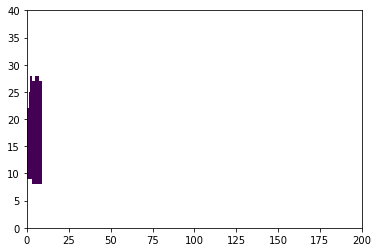

In [60]:
itrack = 10
# ds_wide_dx.CoreArea_up.isel(core=0, tracks=itrack).transpose().plot()
Wmask = ds_wide_dx.Wmask.isel(tracks=itrack).transpose()
Wmask_remove = ds_wide_dx.Wmask_remove.isel(tracks=itrack).transpose()
plt.pcolormesh(Wmask)
plt.pcolormesh(Wmask_remove, alpha=0.5)

## Function to plot individual tracks of updrafts

In [61]:
def plot_tz_sample(xtime, height, da, da_mask, maxETH, cldTop, Wtime_startend, env_dict,
                   cldTop_fit=None, cldBase=None, cbase_depth=None, keep_flag=None, norm=None, arrow_axisfrac=-0.2,
                   xlim=None, ylim=None, xlabel=None, ylabel=None, title=None, legend=None, legend_loc=None,
                   cmap=None, cblabels=None, cbticks=None, fontsize=None, figsize=None, figname=None, dpi=None):
    
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    # mpl.rcParams['font.family'] = 'DejaVu Sans'
    mpl.rcParams['figure.facecolor'] = 'white'

    fig = plt.figure(figsize=figsize, dpi=dpi)
    nrows = 1
    gs = gridspec.GridSpec(nrows, 2, height_ratios=np.repeat(1, nrows).tolist(), width_ratios=[1,0.04])
    gs.update(left=0.05, right=0.9, bottom=0.05, top=0.95, wspace=0.1, hspace=0.15)
    ax = plt.subplot(gs[0,0])
    cax = plt.subplot(gs[0,1])
    
    # Define line/symbol colors/sizes
    colors = {'ETH':'red', 'cldTop':'deepskyblue', 'cldBase':'cyan', 'cldTopFit':'dodgerblue',
              'LCL':'violet', 'LFC':'mediumorchid', 'ENV_time':'deeppink', 'time_s':'purple', 'time_e':'purple',
              'cldBase_layer':'gainsboro',}
    lws = {'ETH':3, 'cldTop':3, 'cldBase':2, 'LCL':1, 'LFC':1, 'cldBase_layer':1}
    markers = {'ETH':'D', 'cldTop':'o'}
    marker_sizes = {'ETH':40, 'cldTop':30}
    
    # Plot data
    pcm_da = ax.pcolormesh(xtime, height, da, shading='nearest', norm=norm, cmap=cmap)
    # Plot mask
    pcm_ma = ax.pcolormesh(xtime, height, da_mask, vmin=0., vmax=1, cmap='gray', alpha=0.8)
    # Updraft start/end time period
    ax.axvline(Wtime_startend['s'], lw=1, color=colors['time_s'])
    ax.axvline(Wtime_startend['e'], lw=1, color=colors['time_s'])
    ax.axvline(max(time_window), lw=1, ls=':', color=colors['time_e'])
    # ETH line
    ETH_line = ax.plot(xtime, maxETH, color=colors['ETH'], lw=lws['ETH'], label='10dBZ ETH')
    # Max ETH
    idx_trackmaxETH = np.nanargmax(maxETH)
    time_trackmaxETH = xtime.values[idx_trackmaxETH]
    ax.scatter(time_trackmaxETH, np.nanmax(maxETH), s=marker_sizes['ETH'], c=colors['ETH'], marker=markers['ETH'], zorder=2)
    
    # cloud/updraft top line
    cldTop_line = ax.plot(xtime, cldTop, color=colors['cldTop'], lw=lws['cldTop'], label='Updraft Top')
    # Max updraft top
    if (np.count_nonzero(~np.isnan(cldTop)) > 0):
        idx_trackmaxcldTop = np.nanargmax(cldTop)
        time_trackmaxcldTop = xtime.values[idx_trackmaxcldTop]
        ax.scatter(time_trackmaxcldTop, np.nanmax(cldTop), s=marker_sizes['cldTop'], c=colors['cldTop'], marker=markers['cldTop'], zorder=3)
    if cldBase is not None:
        cldBase_line = ax.plot(xtime, cldBase, color=colors['cldBase'], lw=lws['cldBase'], label='Updraft Base')
        # Median cloud base height
        median_cldBase = np.nanmedian(cldBase)
        median_cldBase_top = median_cldBase + cbase_depth
        # Plot a box for cloud base layer
        cbase_corners = [(Wtime_startend['s'],median_cldBase),(Wtime_startend['e'],median_cldBase),
                         (Wtime_startend['e'],median_cldBase_top),(Wtime_startend['s'],median_cldBase_top)]
        # Create a polygon patch with the corners
        polygon = mpl.patches.Polygon(cbase_corners, closed=True, edgecolor=colors['cldBase_layer'], facecolor='none', 
                                      lw=lws['cldBase_layer'], hatch='//', zorder=3)
        ax.add_patch(polygon)
        
    # cloud/updraft top fit line
    if cldTop_fit is not None:
        cldTop_fitline = ax.plot(xtime, cldTop_fit, color=colors['cldTopFit'], ls='--', label='Updraft Top (Fit)')
    
    # LCL/LFC lines
    LCL = env_dict['LCL']
    LFC = env_dict['LFC']
    ENV_time = env_dict['ENV_time']
    ax.axvline(ENV_time, color=colors['ENV_time'], lw=2)

    line_length = 50
    LCL_t0 = 0
    LCL_t1 = LCL_t0 + line_length
    LFC_t0 = 30
    LFC_t1 = LFC_t0 + line_length
    ax.hlines(y=LCL, xmin=LCL_t0, xmax=LCL_t1, color=colors['LCL'])
    ax.hlines(y=LFC, xmin=LFC_t0, xmax=LFC_t1, color=colors['LFC'], ls='--')
    LCL_text_x = LCL_t0 + line_length / 2
    LCL_text_y = LCL-0.2
    LFC_text_x = LFC_t0 + line_length / 2
    LFC_text_y = LFC-0.2
    ax.text(LCL_text_x, LCL_text_y, 'LCL', ha='center', va='top', color=colors['LCL'], fontsize=fontsize)
    ax.text(LFC_text_x, LFC_text_y, 'LFC', ha='center', va='top', color=colors['LFC'], fontsize=fontsize)
    
    ax.legend(fontsize=fontsize*0.8, loc=legend_loc)
    # Draw an arrow below xaxis
    ax.annotate("", xy=(1, arrow_axisfrac), xycoords='axes fraction', xytext=(0, arrow_axisfrac), arrowprops=dict(facecolor='black'))
    # # Flag to
    # if keep_flag==True:
    #     track_flag = u'\u2713'
    #     track_color = 'green'
    # else:
    #     track_flag = u'\u2717'
    #     track_color = 'red'
    # if keep_flag is not None:
    #     ax.set_title(track_flag, loc='right', color=track_color)
    ax.set_title(title, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.grid(ls=':', lw=0.7)
    # Colorbar
    cb = plt.colorbar(pcm_da, cax=cax, label=cblabels, ticks=cbticks)
    
    fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
    return fig

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_wide_0082.png


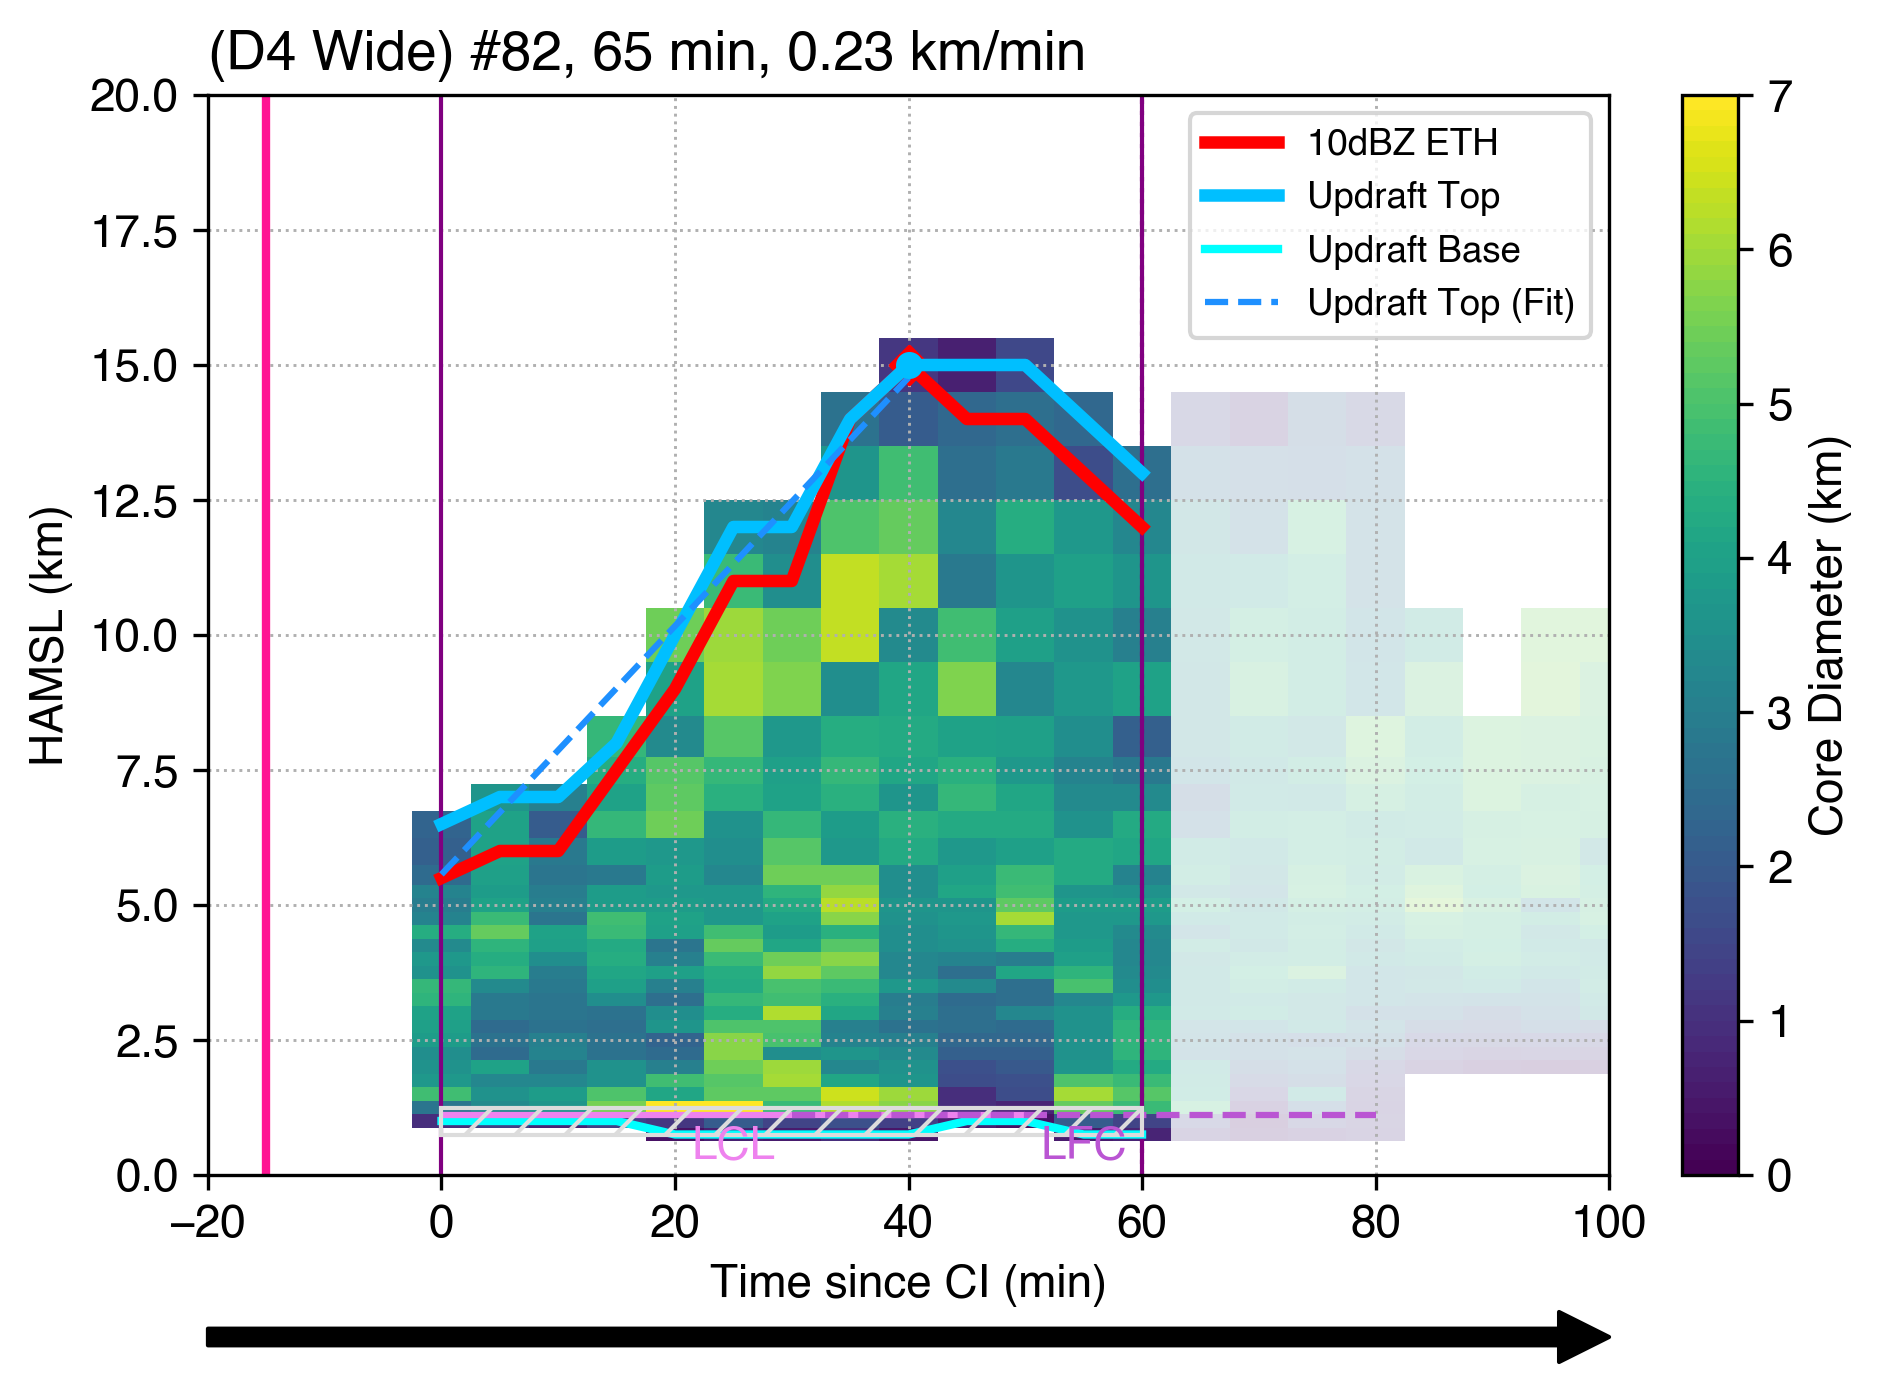

In [ ]:
ETH_buffer = dsnms_dx.attrs['ETH_buffer']
cbase_depth = dsnms_dx.attrs['cbase_depth']

# itrack = 79  # D4 (15 km ETH)
itrack = 82  # D4 (15 km ETH)
# itrack = 90  # D4 (14 km ETH)
# itrack = 95  # D4 (13 km ETH)

# Updraft 
_da_Wmax = ds_wide_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
_da_WDiam = 2 * np.sqrt(ds_wide_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
# 10dBZ ETH
_maxETH = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
_maxETH_full = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack)
# Filter updrafts above 10dBZ ETH + buffer
_da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)

# Updraft quantities
_da_mask = ds_wide_dx.Wmask_remove.isel(tracks=itrack).transpose()
_Wtop = ds_wide_dx.Wtop.isel(tracks=itrack)
_Wbase = ds_wide_dx.Wbase.isel(tracks=itrack)
_t_s = ds_wide_dx.Wtime_start.isel(tracks=itrack) * time_res
_t_e = ds_wide_dx.Wtime_end.isel(tracks=itrack) * time_res
_Wlifetime = ds_wide_dx.Wlifetime.isel(tracks=itrack)
_Wtime_startend = {'s':_t_s, 'e':_t_e}
_WtopMax = _Wtop.max(dim='times').item()
# Convert HAMSL to AGL, then select a representative time before CI
LCL = (ds_wide_dx.LCL_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
LFC = (ds_wide_dx.LFC_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
ENV_time = -15  # environment sample time [min]
_env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
_Wtop_fit = ds_wide_dx.Wtop_fit.isel(tracks=itrack)
_Wtop_slope = ds_wide_dx.Wtop_slope.isel(tracks=itrack)
_keep_flag = wide_tracks_dx.isel(tracks=itrack)

cmap = 'viridis'
cmap = copy.copy(mpl.cm.get_cmap(cmap))
# Shading levels
levels = np.arange(0, 7.01, 0.1)
cbticks = np.arange(0, 7.01, 1)
norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

# Axes
xlim = (-20,100)
# ylim = (0,12)
ylim = (0,20)
# title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
title = f'({domain_name.upper()} Wide) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
xlabel = 'Time since CI (min)'
ylabel = 'HAMSL (km)'
legend_loc = 'upper right'
# cblabels = 'Core Max W (m/s)'
# figbasename = 'CoreMaxW'
arrow_axisfrac = -0.15
cblabels = 'Core Diameter (km)'
figbasename = 'CoreDiam'
figname = f'{figdir}{figbasename}_{domain_name}_wide_{itrack:04}.png'
figsize = (6,4)
fontsize = 11
dpi = 300

fig = plot_tz_sample(xtime, height, _da_WDiam, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                     cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag, norm=norm,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel, legend_loc=legend_loc, arrow_axisfrac=arrow_axisfrac,
                     cmap=cmap, cblabels=cblabels, cbticks=cbticks, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
# plt.close(fig)
print(figname)

In [69]:
# time_coord.shape, height.shape, _da_mask.shape, _da.shape
# figdir
ntracks_wide_dx

149

In [73]:
# Set a seed for reproducibility
np.random.seed(10)

nsamples2plot = 200
if (nsamples2plot > ntracks_wide_dx): 
    nsamples2plot = ntracks_wide_dx
    tracks_random = np.arange(0, nsamples2plot)
else:
    tracks_random = np.random.randint(0, ds_wide_dx.sizes['tracks'], nsamples2plot)

print(len(tracks_random))
tracks_random

149


array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148])

### Plot wide cell updraft core diameter

In [74]:
ETH_buffer = dsnms_dx.attrs['ETH_buffer']
cbase_depth = dsnms_dx.attrs['cbase_depth']

# # Set a seed for reproducibility
# np.random.seed(10)
# nsamples2plot = 100
# if (nsamples2plot > ntracks_wide_dx): nsamples2plot = ntracks_wide_dx
# tracks_random = np.random.randint(0, ds_wide_dx.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
# for itrack in range(0, 1):
    # Updraft 
    _da_Wmax = ds_wide_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
    _da_WDiam = 2 * np.sqrt(ds_wide_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
    # 10dBZ ETH
    _maxETH = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
    _maxETH_full = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack)
    # Filter updrafts above 10dBZ ETH + buffer
    _da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)

    # Updraft quantities
    _da_mask = ds_wide_dx.Wmask_remove.isel(tracks=itrack).transpose()
    _Wtop = ds_wide_dx.Wtop.isel(tracks=itrack)
    _Wbase = ds_wide_dx.Wbase.isel(tracks=itrack)
    _t_s = ds_wide_dx.Wtime_start.isel(tracks=itrack) * time_res
    _t_e = ds_wide_dx.Wtime_end.isel(tracks=itrack) * time_res
    _Wlifetime = ds_wide_dx.Wlifetime.isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    # Convert HAMSL to AGL, then select a representative time before CI
    LCL = (ds_wide_dx.LCL_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
    LFC = (ds_wide_dx.LFC_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
    ENV_time = -15  # environment sample time [min]
    _env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
    _Wtop_fit = ds_wide_dx.Wtop_fit.isel(tracks=itrack)
    _Wtop_slope = ds_wide_dx.Wtop_slope.isel(tracks=itrack)
    _keep_flag = wide_tracks_dx.isel(tracks=itrack)

    # Axes
    xlim = (-5,100)
    ylim = (0,20)
    # title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
    title = f'({domain_name.upper()} Wide) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    # cblabels = 'Core Max W (m/s)'
    # figbasename = 'CoreMaxW'
    cblabels = 'Core Diameter (km)'
    figbasename = 'CoreDiam'
    figname = f'{figdir}{figbasename}_{domain_name}_wide_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 11
    dpi = 200

    fig = plot_tz_sample(xtime, height, _da_WDiam, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
    plt.close(fig)
    print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_wide_0000.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_wide_0001.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_wide_0002.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_wide_0003.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_wide_0004.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_wide_0005.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_wide_0006.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_wide_0007.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_wide_0008.png
/

### Plot wide cell updraft speed

In [83]:
ETH_buffer = dsnms_dx.attrs['ETH_buffer']
cbase_depth = dsnms_dx.attrs['cbase_depth']

# Loop over each track to plot
for itrack in tracks_random:
# for itrack in tracks_random[0:1]:
    # Updraft 
    _da_Wmax = ds_wide_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
    _da_WDiam = 2 * np.sqrt(ds_wide_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
    # 10dBZ ETH
    _maxETH = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
    _maxETH_full = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack)
    # Filter updrafts above 10dBZ ETH + buffer
    _da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)
    _da_Wmax = _da_Wmax.where(height <= _maxETH_full+ETH_buffer)

    # Updraft quantities
    _da_mask = ds_wide_dx.Wmask_remove.isel(tracks=itrack).transpose()
    _Wtop = ds_wide_dx.Wtop.isel(tracks=itrack)
    _Wbase = ds_wide_dx.Wbase.isel(tracks=itrack)
    _t_s = ds_wide_dx.Wtime_start.isel(tracks=itrack) * time_res
    _t_e = ds_wide_dx.Wtime_end.isel(tracks=itrack) * time_res
    _Wlifetime = ds_wide_dx.Wlifetime.isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    # Convert HAMSL to AGL, then select a representative time before CI
    LCL = (ds_wide_dx.LCL_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
    LFC = (ds_wide_dx.LFC_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
    ENV_time = -15  # environment sample time [min]
    _env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
    _Wtop_fit = ds_wide_dx.Wtop_fit.isel(tracks=itrack)
    _Wtop_slope = ds_wide_dx.Wtop_slope.isel(tracks=itrack)
    _keep_flag = wide_tracks_dx.isel(tracks=itrack)

    # Axes
    xlim = (-5,100)
    ylim = (0,20)
    # title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
    title = f'({domain_name.upper()} Wide) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Diameter (km)'
    # figbasename = 'CoreDiam'
    figname = f'{figdir}{figbasename}_{domain_name}_wide_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 11
    dpi = 200

    fig = plot_tz_sample(xtime, height, _da_Wmax, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
    plt.close(fig)
    print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_wide_0000.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_wide_0001.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_wide_0002.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_wide_0003.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_wide_0004.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_wide_0005.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_wide_0006.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_wide_0007.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_wide_0008.png
/

In [ ]:
# Set a seed for reproducibility
np.random.seed(10)
nsamples2plot = 100
if (nsamples2plot > ntracks_narrow_dx): nsamples2plot = ntracks_narrow_dx
tracks_random = np.random.randint(0, ds_narrow_dx.sizes['tracks'], nsamples2plot)
tracks_random

array([265, 125,  15, 320, 369, 123, 156, 221, 369,   8,  73, 256,  40,
       371,  16, 356, 239,  54, 344, 363, 122,  62,  33, 200, 356, 177,
       179,  54,  77,  13, 243, 382, 141, 348, 342, 286, 158,  89, 140,
       321,  31, 313, 292, 283,  18,  93,  77,  94, 248, 156,  74, 216,
        15,  18, 118,  71, 344, 145, 135, 203, 284, 289, 250, 352,  44,
       133,   4,  71, 344, 344, 306, 364, 182, 290, 360, 271, 344, 143,
       134, 246,  85, 234, 150,  11, 112, 268, 220,  62, 185,  79, 364,
       232,  42, 237, 313, 235, 353, 306,  45, 201])

In [ ]:
# # Set a seed for reproducibility
# np.random.seed(10)
# nsamples2plot = 100
# if (nsamples2plot > ntracks_narrow_dx): nsamples2plot = ntracks_narrow_dx
# tracks_random = np.random.randint(0, ds_narrow_dx.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
# for itrack in range(0, 1):
    # Updraft 
    _da_Wmax = ds_narrow_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
    _da_WDiam = 2 * np.sqrt(ds_narrow_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
    # 10dBZ ETH
    _maxETH = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
    _maxETH_full = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack)
    # Filter updrafts above 10dBZ ETH + buffer
    _da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)

    # Updraft quantities
    _da_mask = ds_narrow_dx.Wmask_remove.isel(tracks=itrack).transpose()
    _Wtop = ds_narrow_dx.Wtop.isel(tracks=itrack)
    _Wbase = ds_narrow_dx.Wbase.isel(tracks=itrack)
    _t_s = ds_narrow_dx.Wtime_start.isel(tracks=itrack) * time_res
    _t_e = ds_narrow_dx.Wtime_end.isel(tracks=itrack) * time_res
    _Wlifetime = ds_narrow_dx.Wlifetime.isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    # Convert HAMSL to AGL, then select a representative time before CI
    LCL = (ds_narrow_dx.LCL_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
    LFC = (ds_narrow_dx.LFC_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
    ENV_time = -15  # environment sample time [min]
    _env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
    _Wtop_fit = ds_narrow_dx.Wtop_fit.isel(tracks=itrack)
    _Wtop_slope = ds_narrow_dx.Wtop_slope.isel(tracks=itrack)
    _keep_flag = narrow_tracks_dx.isel(tracks=itrack)

    # Axes
    xlim = (-5,100)
    ylim = (0,12)
    # title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
    title = f'({domain_name.upper()} Narrow) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    # cblabels = 'Core Max W (m/s)'
    # figbasename = 'CoreMaxW'
    cblabels = 'Core Diameter (km)'
    figbasename = 'CoreDiam'
    figname = f'{figdir}{figbasename}_{domain_name}_narrow_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 11
    dpi = 200

    print(figname)
    fig = plot_tz_sample(xtime, height, _da_WDiam, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
    plt.close(fig)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_narrow_0265.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_narrow_0125.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_narrow_0015.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_narrow_0320.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_narrow_0369.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_narrow_0123.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_narrow_0156.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4_narrow_0221.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreDiam_d4

In [ ]:
# ETH_buffer = dsnms_dx.attrs['ETH_buffer']
# cbase_depth = dsnms_dx.attrs['cbase_depth']

# # Set a seed for reproducibility
# np.random.seed(10)
# nsamples2plot = 100
# if (nsamples2plot > ntracks_narrow_dx): nsamples2plot = ntracks_narrow_dx
# tracks_random = np.random.randint(0, ds_narrow_dx.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
# for itrack in tracks_random[0:1]:
    # Updraft 
    _da_Wmax = ds_narrow_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
    _da_WDiam = 2 * np.sqrt(ds_narrow_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
    # 10dBZ ETH
    _maxETH = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
    _maxETH_full = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack)
    # Filter updrafts above 10dBZ ETH + buffer
    _da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)
    _da_Wmax = _da_Wmax.where(height <= _maxETH_full+ETH_buffer)

    # Updraft quantities
    _da_mask = ds_narrow_dx.Wmask_remove.isel(tracks=itrack).transpose()
    _Wtop = ds_narrow_dx.Wtop.isel(tracks=itrack)
    _Wbase = ds_narrow_dx.Wbase.isel(tracks=itrack)
    _t_s = ds_narrow_dx.Wtime_start.isel(tracks=itrack) * time_res
    _t_e = ds_narrow_dx.Wtime_end.isel(tracks=itrack) * time_res
    _Wlifetime = ds_narrow_dx.Wlifetime.isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    # Convert HAMSL to AGL, then select a representative time before CI
    LCL = (ds_narrow_dx.LCL_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
    LFC = (ds_narrow_dx.LFC_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
    ENV_time = -15  # environment sample time [min]
    _env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
    _Wtop_fit = ds_narrow_dx.Wtop_fit.isel(tracks=itrack)
    _Wtop_slope = ds_narrow_dx.Wtop_slope.isel(tracks=itrack)
    _keep_flag = narrow_tracks_dx.isel(tracks=itrack)

    # Axes
    xlim = (-5,100)
    ylim = (0,12)
    # title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
    title = f'({domain_name.upper()} Narrow) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Diameter (km)'
    # figbasename = 'CoreDiam'
    figname = f'{figdir}{figbasename}_{domain_name}_narrow_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 11
    dpi = 200

    fig = plot_tz_sample(xtime, height, _da_Wmax, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
    plt.close(fig)
    print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_narrow_0265.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_narrow_0125.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_narrow_0015.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_narrow_0320.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_narrow_0369.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_narrow_0123.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_narrow_0156.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4_narrow_0221.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/updraft_tracks_narrowwide/CoreMaxW_d4